# Exploratory Data Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\kumar_santhosh\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\kumar_santhosh\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
df = pd.read_csv('cleaned_data.csv')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
education_level_distribution = df['Education'].value_counts()
education_level_distribution

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

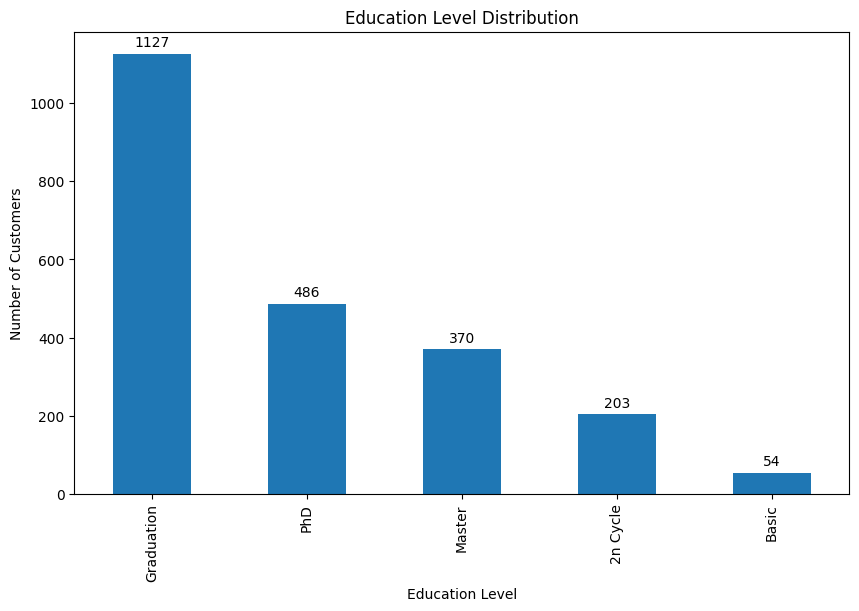

In [11]:
plt.figure(figsize=(10,6))
ax = df['Education'].value_counts().plot(kind= 'bar')
plt.bar_label(ax.containers[0], padding=3)
plt.title('Education Level Distribution')
plt.xlabel('Education Level')
plt.ylabel('Number of Customers')
plt.show()

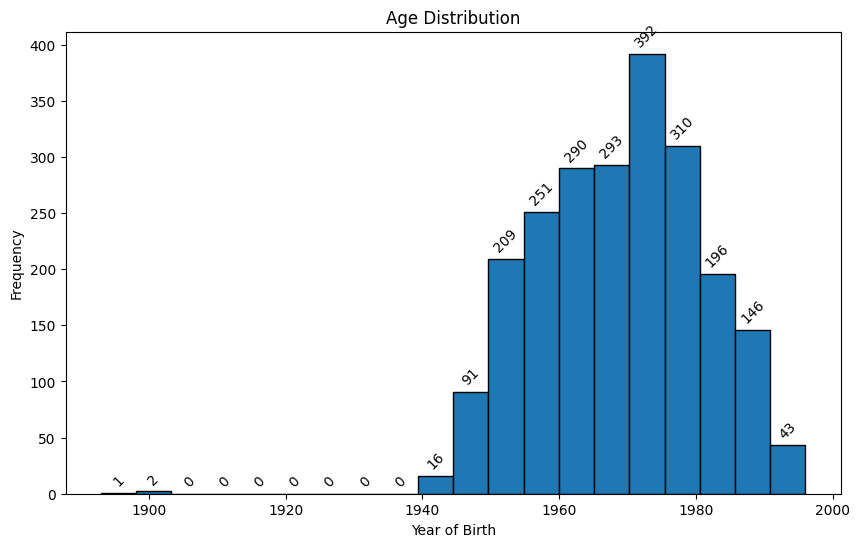

In [14]:
plt.figure(figsize=(10,6))
ax = df['Year_Birth'].plot(kind='hist', bins=20, edgecolor='black')
plt.bar_label(ax.containers[0], padding=3, rotation=45)
plt.title('Age Distribution')
plt.xlabel('Year of Birth')
plt.ylabel('Frequency')
plt.show()

In [18]:
df['ID'].nunique()

2240

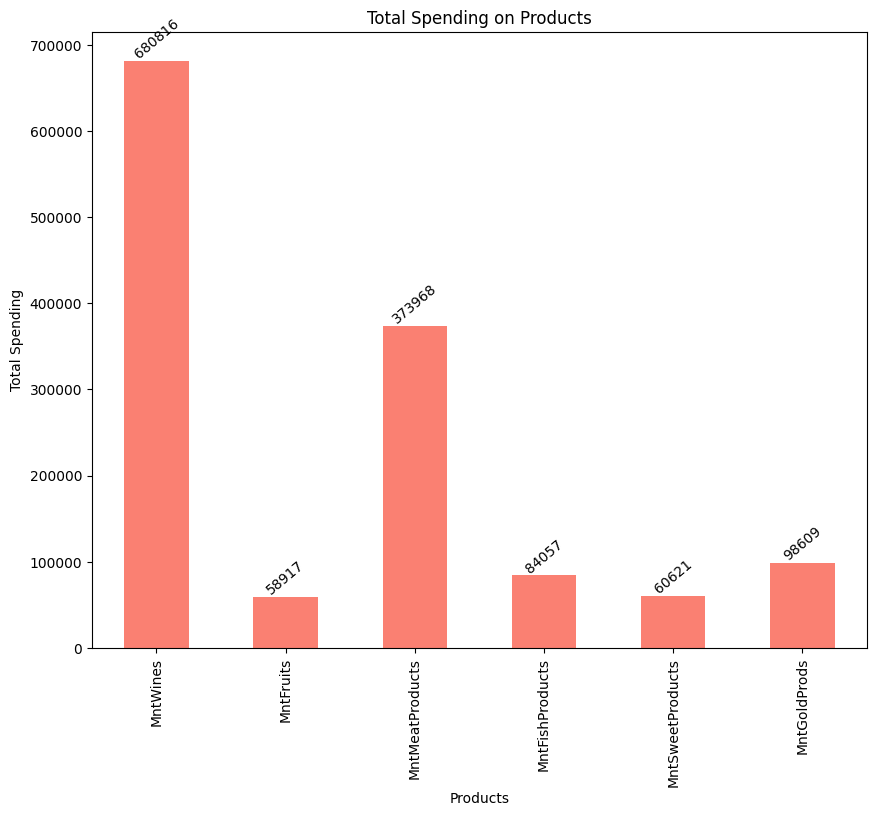

In [19]:
products = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
total_spent = df[products].sum()

plt.figure(figsize=(10,8))

ax = total_spent.plot(kind='bar', color='salmon')
plt.bar_label(ax.containers[0], rotation = 40)
plt.title('Total Spending on Products')
plt.xlabel('Products')
plt.ylabel('Total Spending')
plt.show()

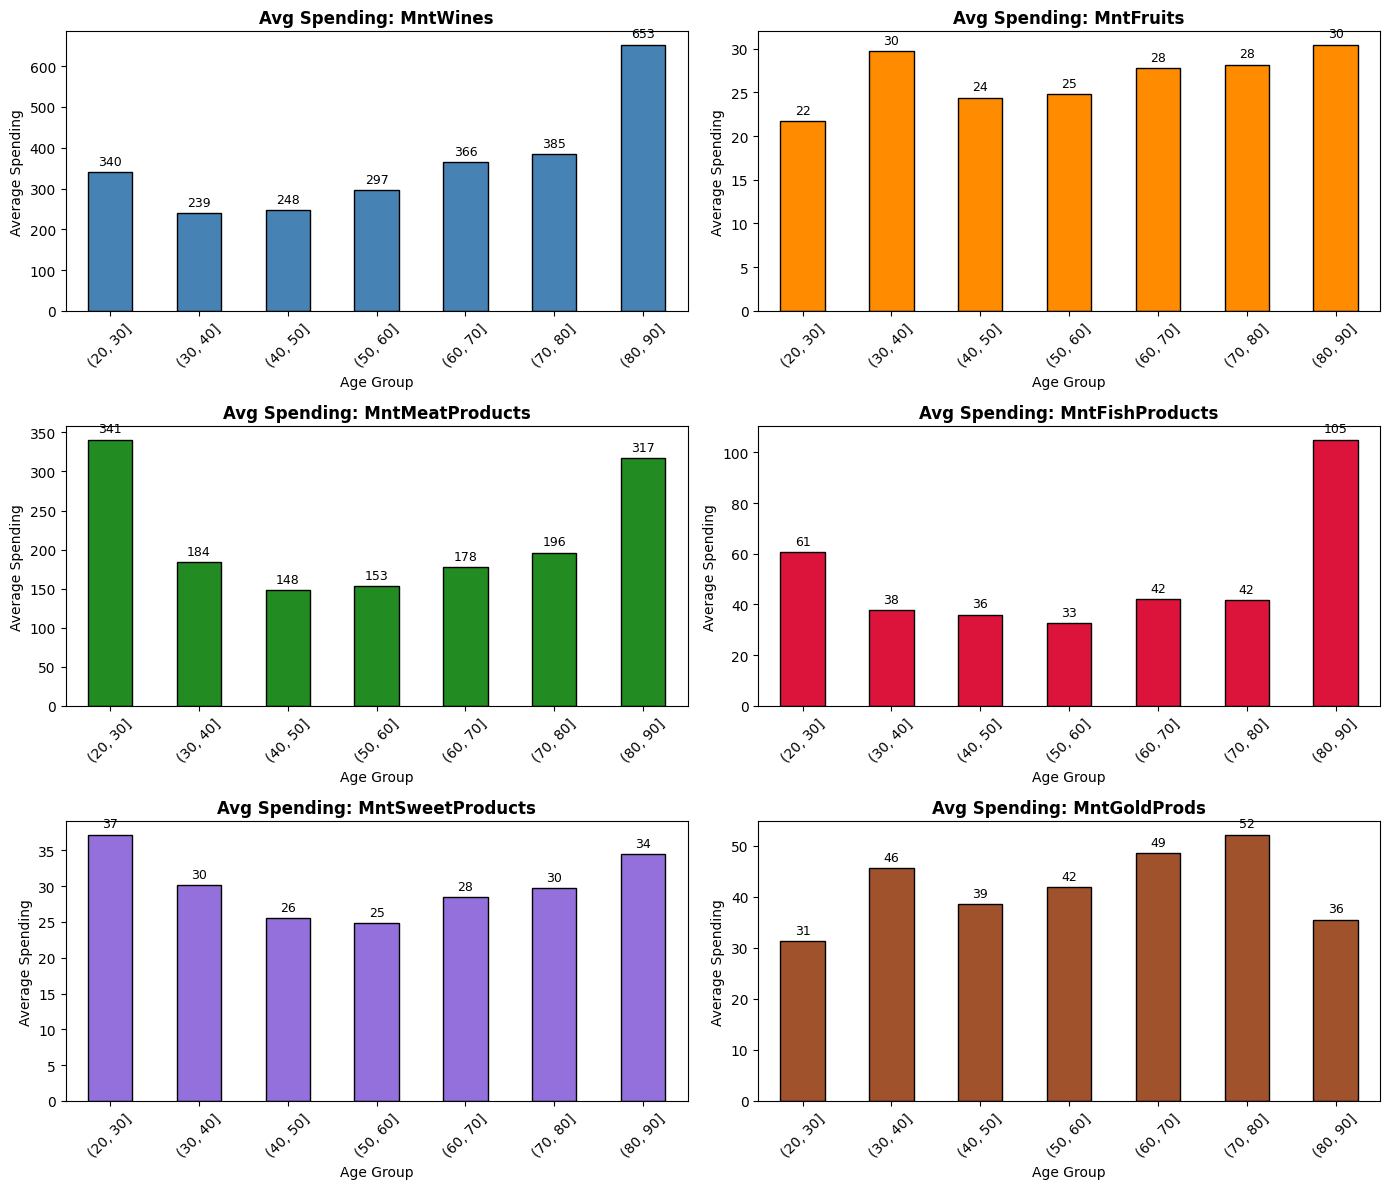

In [27]:
df['Age'] = 2024 - df['Year_Birth']
age_bins = [20, 30, 40, 50, 60, 70, 80, 90]
df['Age_Group'] = pd.cut(df['Age'], bins=age_bins)
spending_by_age = df.groupby('Age_Group', observed=False)[products].mean()
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))
axes = axes.flatten()
colors = ['steelblue', 'darkorange', 'forestgreen', 'crimson', 'mediumpurple', 'sienna']
for i, product in enumerate(products):
    ax = axes[i]
    spending_by_age[product].plot(kind='bar', ax=ax, color=colors[i], edgecolor='black')
    ax.bar_label(ax.containers[0], padding=3, fmt='%.0f', fontsize=9)
    ax.set_title(f'Avg Spending: {product}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Average Spending')
    ax.set_xlabel('Age Group')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [28]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Age_Group
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,0,0,0,0,0,3,11,1,67,"(60, 70]"
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,0,0,0,0,0,3,11,0,70,"(60, 70]"
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,0,0,0,0,0,3,11,0,59,"(50, 60]"
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,0,0,0,0,0,3,11,0,40,"(30, 40]"
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,0,0,0,0,0,3,11,0,43,"(40, 50]"


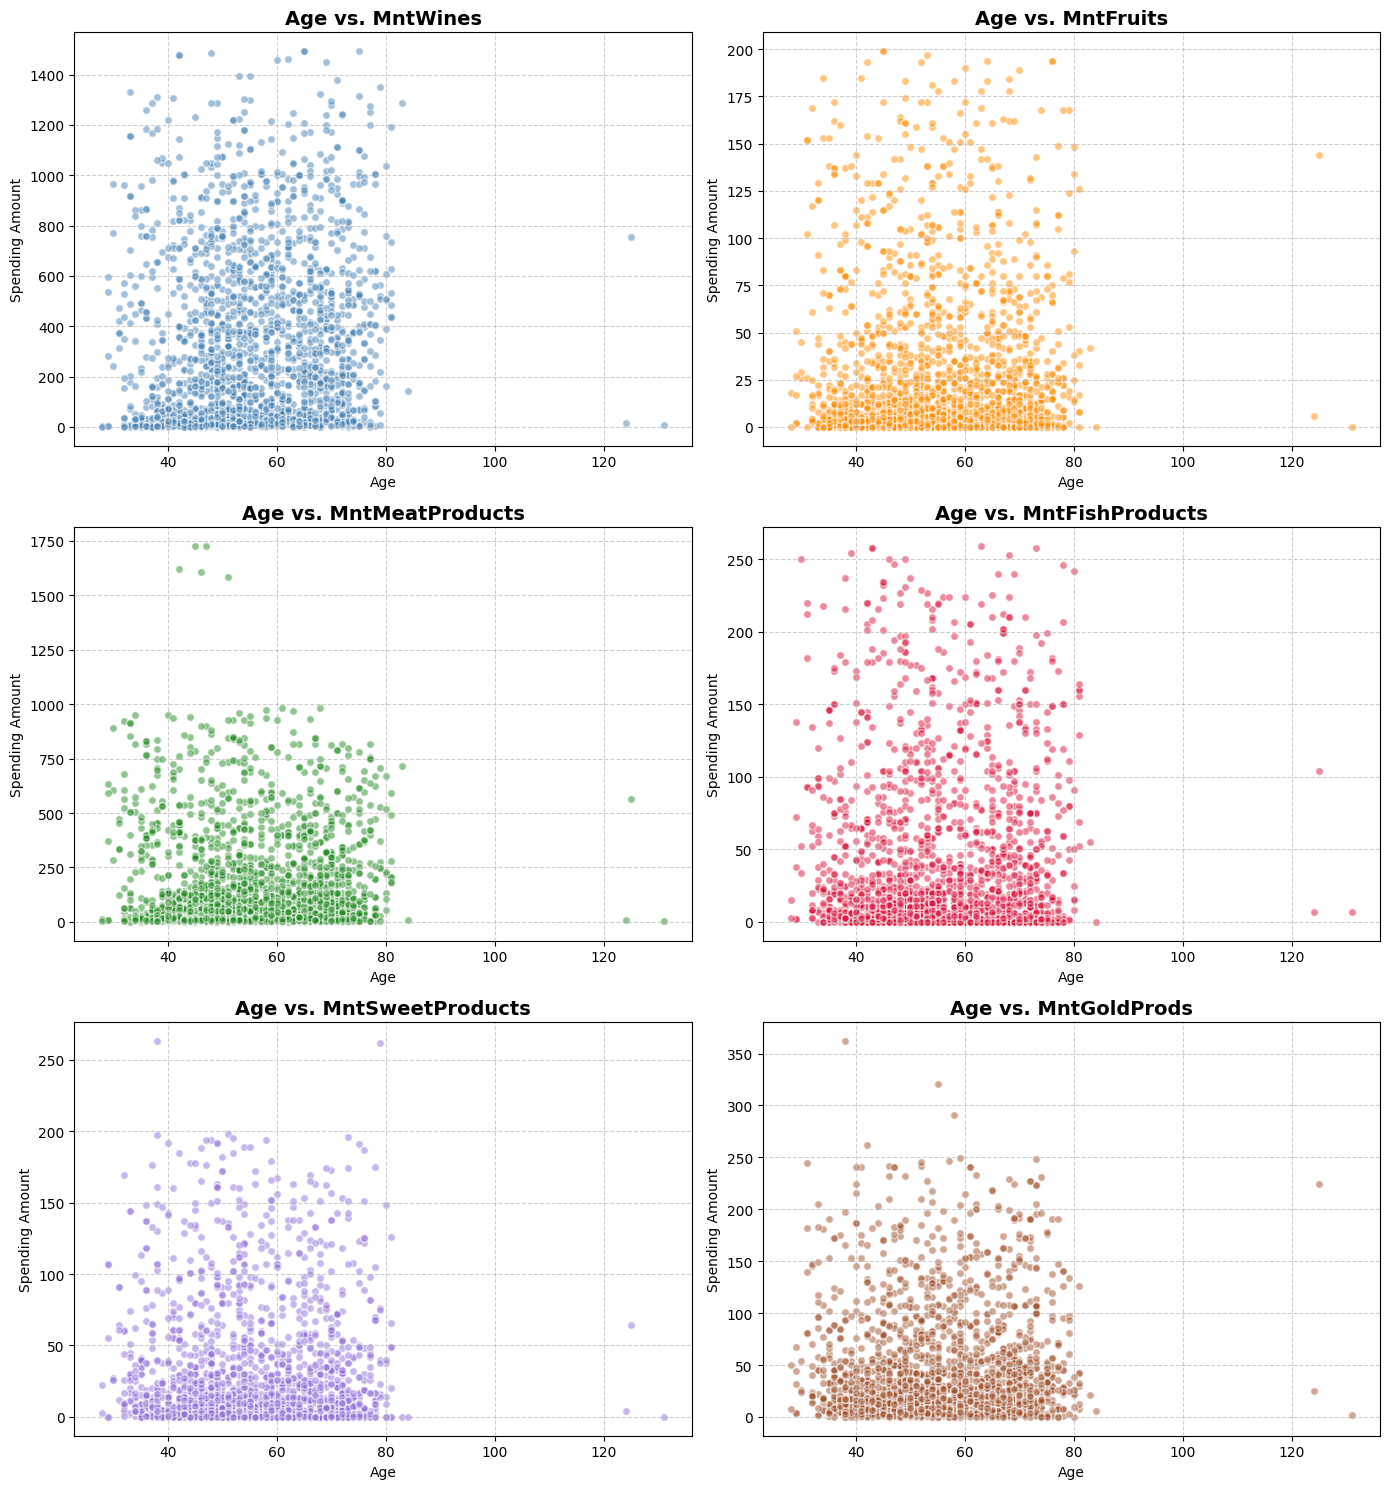

In [32]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 15))
axes = axes.flatten()
colors = ['steelblue', 'darkorange', 'forestgreen', 'crimson', 'mediumpurple', 'sienna']
for i, product in enumerate(products):
    ax = axes[i]
    ax.scatter(df['Age'], df[product], color=colors[i], alpha=0.5, edgecolor='white', s=30)
    ax.set_title(f'Age vs. {product}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Age')
    ax.set_ylabel('Spending Amount')
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

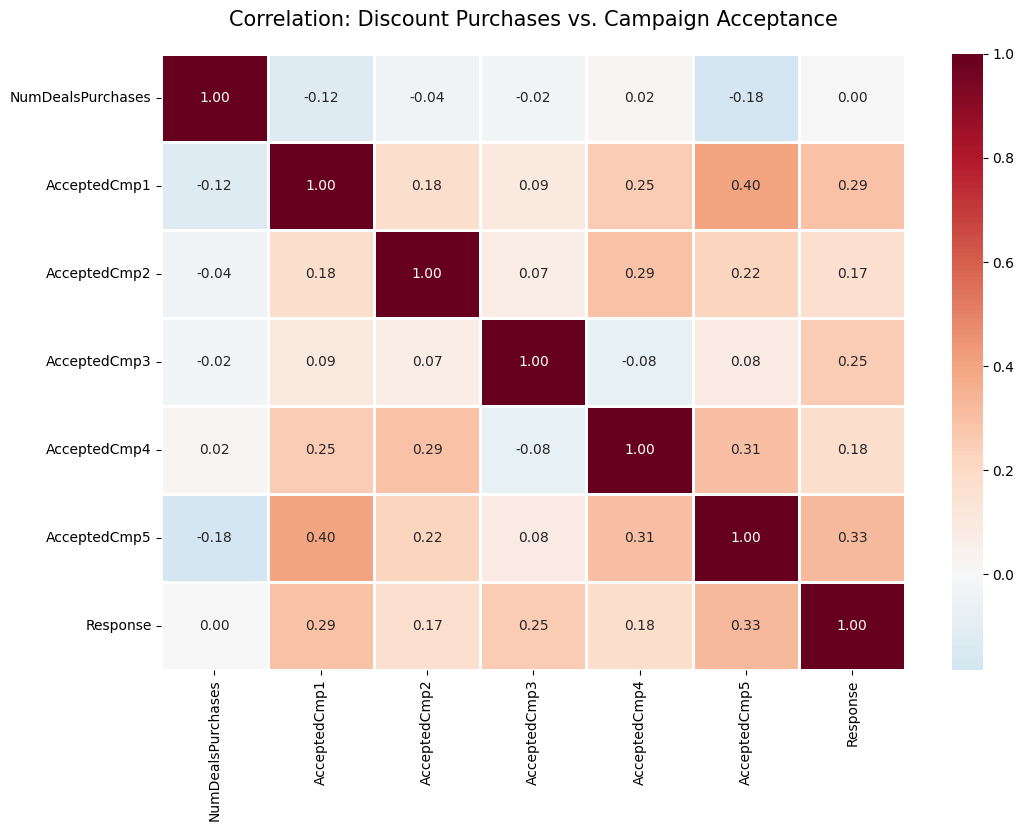

In [33]:
campaign_cols = [ 'NumDealsPurchases', 
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 
    'AcceptedCmp4', 'AcceptedCmp5', 'Response']

campaign_corr = df[campaign_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(campaign_corr, 
            annot=True,
            cmap='RdBu_r',
            center=0, 
            fmt=".2f", 
            linewidths=1, 
            linecolor='white')

plt.title('Correlation: Discount Purchases vs. Campaign Acceptance', fontsize=15, pad=20)
plt.show()